# Impact of turbidity on density

In Fiol et al. "Ice shelf basal melting in giant proglacial lakes", we work in density anomaly: 

$d_a=\frac{\rho(S,T,z)-\rho(S_0,T_0,z)}{\rho_0}$

where $S_0$ and $T_0$ are the reference salinity and temperature, respectively, and $\rho_0$ is the reference density, i.e., the density at $T_0$, $S_0$, and at surface pressure.

At the surface, this equation becomes:

$d_{a,surf}=\frac{\rho(S,T,0)}{\rho_0}-1=\frac{\rho_{surf}(S,T)}{\rho_0}-1$

In Sugiyama et al. 2016, they give an equation of density taking into account the turbidity (equation below). The equation is given for 1~atm (so at the surface). (In the article they talk about "bulk density of lake water [..] at 1 atm")

$\rho^\star(T,SSC) = \Big(1 - \frac{SSC}{\rho_s}\Big) \rho_{surf}(0,T) + SSC$

where $SSC$ is the suspended sediment concentration in $\mathrm{kg\,m^{-3}}$, $\rho_s$ is the density of suspended particles (Chikita et al. 1999; Sugiyama et al. 2016, typically 2730 $\mathrm{kg\,m^{-3}}$), and $\rho_{surf}(0,T)$ in $\mathrm{kg\,m^{-3}}$ is the density of pure water at temperature $T$ at the surface (Sugiyama et al. 2016). 

In the following, we consider that we have no salinity and we are at the surface of the lake.

We can define $d_{a,surf}$ for the density taking into account turbidity:

$d^\star_{a,surf}  =\frac{\Big(1 - \frac{SSC}{\rho_s}\Big) \rho_{surf}(0,T) + SSC}{\rho_0}-1$

$d^\star_{a,surf}  = \Big(1 - \frac{SSC}{\rho_s}\Big) d_{a,surf}(0,T) + \frac{SSC + \Big(1 - \frac{SSC}{\rho_s}\Big)\rho_0}{\rho_0}-1$

$d^\star_{a,surf}  = \Big(1 - \frac{SSC}{\rho_s}\Big) d_{a,surf}(0,T) - \frac{SSC}{\rho_s} + \frac{SSC}{\rho_0}$

We can compute $\alpha^\star_{surf}$:

$\alpha^\star_{surf} = - \frac{\partial d^\star_{a,surf}}{\partial T} = \Big(1 - \frac{SSC}{\rho_s}\Big) \alpha_{surf}(0,T)$

As in Sugiyama et al. 2016, SSC varies between 0 and 0.8~\unit{kg\,m^{-3}}, $\alpha^\star_{surf}$ is of the same sign of $\alpha_{surf}(0,T)$.

Now let's compute $d(d^\star_a)/dm$.

$\displaystyle{\frac{d(d^\star_a)}{dm}} = \displaystyle \frac{\partial (d^\star_a)}{\partial SSC} \frac{\partial SSC}{\partial m} + \frac{\partial (d^\star_a)}{\partial T} \frac{\partial T}{\partial m}$ 

To analyse the sign of $\displaystyle{\frac{d(d^\star_a)}{dm}}$, we consider that we have no salinity and that we are at the surface of the lake. We follow the same reasoning as in the paper but considering turbidity instead of salinity.

Alike for salinity, we define: 

$\displaystyle\frac{d(SSC)}{dm} = - SSC\frac{t_f \, sc}{\rho_0 \, V}$. 

In addition, we have: 

$\displaystyle{\frac{d(d^\star_{a,surf})}{dSSC}} = \frac{1}{\rho_0}-\frac{d_{a,surf}(0,T)+1}{\rho_s}$

And so we have:

$\displaystyle{\frac{d(d^\star_{a,surf})}{dm}} =  \displaystyle \frac{d (d^\star_{a,surf})}{d SSC} \frac{d SSC}{d m} + \frac{d (d^\star_{a,surf})}{d T} \frac{d T}{d m}$

$\displaystyle{\frac{d(d^\star_{a,surf})}{dm}} =  \displaystyle -\Big( \frac{1}{\rho_0}-\frac{d_{a,surf}(0,T)+1}{\rho_s} \Big)SSC\frac{t_f \, sc}{\rho_0 \, V} + \Big(1 - \frac{SSC}{\rho_s}\Big) \alpha_{surf}(0,T) \frac{L \, t_f \, sc}{\rho_0 \, V \, c_{pw}}$

$\displaystyle{\frac{d(d^\star_{a,surf})}{dm}} = \displaystyle \underbrace{\Big( \frac{sc \ t_f}{V \, \rho_0} \Big)}_\mathrm{>0} \quad \Big[ \underbrace{\Big(\frac{d_{a,surf}(0,T)+1}{\rho_s} - \frac{1}{\rho_0} \Big)SSC + \Big(1 - \frac{SSC}{\rho_s}\Big)\frac{\alpha_{surf}(0,T) \, L}{c_{pw}} \Big]}_{sign \ derivative}$

We can also define a Thermal Over Turbid ratio (ThOTu) similar to TOH ratio of the paper:

$\mathrm{ThOTu} = \displaystyle\frac{\frac{d (d^\star_a)}{d T} \frac{d T}{d m}}{\frac{d (d^\star_a)}{d SSC} \frac{d SSC}{d m}} =  \frac{\Big(1 - \frac{SSC}{\rho_s}\Big)\frac{\alpha_{surf}(0,T) \, L}{c_{pw}}}{\Big(\frac{d_{a,surf}(0,T)+1}{\rho_s} - \frac{1}{\rho_0} \Big)SSC}$

We can so do a T-turbidity diagram as Figure 1. of the paper but plotting ThOTu and the sign of $\displaystyle{\frac{d(d^\star_a)}{dm}}$ (at the surface and considering salinity equals 0.

In [1]:
#import libraries needed
import numpy as np
import matplotlib.pyplot as plt

### Define some functions

In [2]:
def da(SA,CT,z,a0,b0,l1,l2,nu,mu1,mu2):
    """
    Calculate the density anomaly using the simplified equation of state presented in Fiol et al. "Ice shelf basal melting in giant proglacial lakes".

    Parameters
    ----------
    SA : Absolute Salinity (g/kg)
    CT : Conservative Temperature (°C)
    z : depth (m) (equal to zero at the surface and positive towards depth)
    a0, b0, l1, l2, nu, mu1, mu2 : some coefficients

    Returns
    -------
    da : density anomaly (-)
    """
    
    global T0,S0,rho0
    Sanom=SA-S0 #salinity anomaly
    Tanom=CT-T0 #temperature anomaly

    #computation
    da=(-a0*(1+0.5*l1*Tanom+mu1*z)*Tanom+b0*(1-0.5*l2*Sanom-mu2*z)*Sanom-nu*Tanom*Sanom)/rho0
    return da

In [3]:
def alphaSEOS(SA,CT,z,a0,l1,mu1,nu):
    """
    Calculate the thermal expansion coefficient alpha.
    
    Alpha is calculated using the simplified equation of state presented in Fiol et al. "Ice shelf basal melting in giant proglacial lakes".

    Parameters
    ----------
    SA : Absolute Salinity (g/kg)
    CT : Conservative Temperature (°C)
    z : depth (m) (equal to zero at the surface and positive towards depth)
    a0, lambda1, mu1, nu : some coefficients

    Returns
    -------
    alpha : thermal expansion coefficient (1/°C)
    """
    
    global rho0,S0,T0 #reference density, reference salinity, reference temperature
    
    Sanom=SA-S0 #salinity anomaly
    Tanom=CT-T0 #temperature anomaly

    #computation
    alpha=(1/rho0)*(a0*(1+l1*Tanom+mu1*z)+nu*Sanom)
    return alpha

### Some useful variables

In [4]:
#variables linked to the equation of state
rhofw=1000.0 ; rho0=1000.38 ; S0=0.5 ; T0=4.0 #density of fresh water, reference density, reference salinity, reference temperature
print(rhofw,rho0,S0,T0)
coefs=[-2.274e-03,8.0228e-01,-6.121,1.3726e-02,3.3176e-03,-1.279e-02,1.135e-05] #coefficients of the simplified equation of state
print(coefs[0],coefs[1],coefs[2],coefs[3],coefs[4],coefs[5],coefs[6])
coefs_alpha=[-2.274e-03,-6.121,-1.279e-02,3.3176e-03] #coefficients to compute alpha
print(coefs_alpha[0],coefs_alpha[1],coefs_alpha[2],coefs_alpha[3])
##for turbidity
rhos=2730
print(rhos)

1000.0 1000.38 0.5 4.0
-0.002274 0.80228 -6.121 0.013726 0.0033176 -0.01279 1.135e-05
-0.002274 -6.121 -0.01279 0.0033176
2730


In [5]:
#some other variables
L= 0.334e6 #latent heat of fusion of ice (J/kg)
cp= 4204.5837 #isobaric specific heat capacity of water (J/(kg*K))
g=9.80665 #gravity parameter (m/s2)
print(L,cp,g)

334000.0 4204.5837 9.80665


## Some computations

In [6]:
#define the ranges of interest
taille=501 

#inferior and superior limits
SSCmin=0 ; SSCmax=1
CTmin=-1 ; CTmax=10

#define the vectors
liste_SSC=np.linspace(SSCmin,SSCmax,taille)
liste_CT=np.linspace(CTmin,CTmax,taille)
#print(len(liste_SSC),liste_SSC,len(liste_CT),liste_CT)

In [7]:
#compute ThOTu and the sign of the melt derivative of density 
rapport=np.ones((len(liste_SSC),len(liste_CT)))*np.nan 
signe=np.ones((len(liste_SSC),len(liste_CT)))*np.nan 

turb=(1+da(0,liste_CT,0,coefs[0],coefs[1],coefs[2],coefs[3],coefs[4],coefs[5],coefs[6]))/rhos-1/rho0
therm=(L/cp)*alphaSEOS(0,liste_CT,0,coefs_alpha[0],coefs_alpha[1],coefs_alpha[2],coefs_alpha[3])

for iSSC in range(len(liste_SSC)):
    if liste_SSC[iSSC]>0:
        rapport[iSSC,:]=(therm*(1-liste_SSC[iSSC]/rhos))/(turb*liste_SSC[iSSC])
    signe[iSSC,:]=turb*liste_SSC[iSSC]+therm*(1-liste_SSC[iSSC]/rhos)

#compute the decimal logarithm of the absolute value of ThOTu
rapport10=np.log10(np.abs(rapport))

### Graphical display

Text(0, 0.5, 'SSC (kg/m3)')

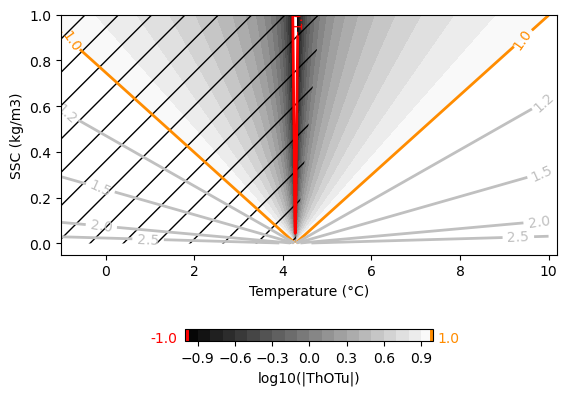

In [ ]:
#create the figure
cf=plt.contourf(liste_CT,liste_SSC,rapport10,levels=np.linspace(-1,1,21),zorder=-1,cmap="gist_yarg_r")
c=plt.contour(liste_CT,liste_SSC,rapport10,levels=[-1,1,1.2,1.5,2,2.5],colors=["red","darkorange","silver","silver","silver","silver"],zorder=0,linewidths=2)
plt.clabel(c, inline=True)#, fontsize=16)
cfhatches_GL=plt.contourf(liste_CT,liste_SSC,signe,levels=[np.min(signe),0,np.max(signe)],colors="none",hatches=['/',None],zorder=-1)
#customise hatches
for collection_GL in cfhatches_GL.collections:
    collection_GL.set_edgecolor("black")
    collection_GL.set_linewidth(0.)

#colorbar
cbartsp=plt.colorbar(cf,location="bottom",pad=0.2,shrink=0.5)
cbartsp.set_label(label="log10(|ThOTu|)")#,size=20)
#cbartsp.ax.tick_params(labelsize=18)
cbartsp.add_lines([-1,1],colors=["red","darkorange"],linewidths=5)
plt.text(1,-0.43,'-1.0',color="red")#,size=18)
plt.text(7.5,-0.43,'1.0',color="darkorange")#,size=18)

#axes labels
plt.xlim(-1,10.2)
plt.ylim(-0.05,1)
plt.xlabel("Temperature (°C)")#,fontsize=20)
plt.ylabel("SSC (kg/m3)")#,fontsize=20)
